In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd()  

sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / "py_modules"))

from pipeline_config import MAPS_DIR, FIGS_DIR
import results_comp

In [2]:
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt


def load_multi_line_bin_results(
    results_comp,
    maps_dir,
    *,
    dataset_prefix="MUSE-M42",
    line_order=("H", "N", "O", "S", "Ar"),
    bin_levels=(0, 1, 2, 3, 4),
    read_header=True,
    fit_key="fit",
):
    """
    Load fit results for several emission lines and binning levels.

    It assumes file names like:

        MUSE-M42-H-bin0
        MUSE-M42-H-bin1
        MUSE-M42-N-bin0
        MUSE-M42-Ar-bin4

    Parameters
    ----------
    results_comp : module
        Module that contains load_line_bundle_mat.

    maps_dir : str or pathlib.Path
        Directory where the result files are stored.

    dataset_prefix : str
        Common prefix of the files. Default is "MUSE-M42".

    line_order : tuple or list of str
        Lines to load, in the desired plotting order.

    bin_levels : tuple or list of int
        Binning levels to load.

    read_header : bool
        Passed to results_comp.load_line_bundle_mat.

    fit_key : str
        Key used to access the fit table inside each loaded bundle.

    Returns
    -------
    data_in : list of dict
        Flat list with one dictionary per line/bin sample.

        Each entry has:
            line
            bin
            label
            file_name
            bundle
            fit
            fit_dict
            meta
    """

    data_in = []

    for line in line_order:
        for bin_level in bin_levels:
            file_name = f"{dataset_prefix}-{line}-bin{bin_level}"
            internal_name = f"{line}_bin{bin_level}_line"

            bundle = results_comp.load_line_bundle_mat(
                file_name,
                internal_name,
                maps_dir,
                read_header=read_header,
            )

            fit = bundle[fit_key]
            fit_dict = fit.to_dict(orient="list")

            entry = {
                "line": line,
                "bin": bin_level,
                "label": f"{line}{bin_level}",
                "file_name": file_name,
                "bundle": bundle,
                "fit": fit,
                "fit_dict": fit_dict,
                "meta": bundle.get("meta", {}),
            }

            data_in.append(entry)

    return data_in

In [3]:
#import plot_fit_params

data_in = load_multi_line_bin_results(
    results_comp,
    MAPS_DIR,
    dataset_prefix="MUSE-M42",
    line_order=("H", "N", "O", "S", "Ar"),
    bin_levels=(0, 1, 2, 3, 4),
    read_header=True,
)

## Mod

In [4]:
def plot_param_grid_lines_bins(
    data_in,
    *,
    params=("sig2", "r0", "m", "noise", "s0"),
    line_order=("H", "N", "O", "S", "Ar"),
    bin_levels=(0, 1, 2, 3, 4),
    xtick_labels=None,
    line_legend_labels=None,
    param_labels=None,
    param_titles=None,
    param_ylims=None,
    row_titles=("Physical parameters", "Nuisance parameters"),
    row_title_fontsize=16,
    row_title_y=1.22,
    decimals=4,
    figsize=(15, 8),
    color_palette="Greys_d",
    markers=("o", "s", "^", "D", "P"),
    jitter=0.08,
    capsize=4,
    elinewidth=1.8,
    markersize=6,
    legend_fontsize=13,
    legend_title_fontsize=14,
    show_values=False,
    true=None,
    save=False,
    savepath="fit_parameters_grid.pdf",
):
    """
    Plot fit parameters for several lines and binning levels in a 3 x 2 grid.

    Layout
    ------
    First row:
        sig2, r0, m

    Second row:
        noise, s0, legend

    Parameters
    ----------
    data_in : list of dict
        Output from load_multi_line_bin_results.

        Each entry must contain:
            entry["line"]
            entry["bin"]
            entry["fit_dict"]

        where fit_dict has the format:
            {
                "sig2":  [value, upper_error, lower_error],
                "r0":    [value, upper_error, lower_error],
                "m":     [value, upper_error, lower_error],
                "s0":    [value, upper_error, lower_error],
                "noise": [value, upper_error, lower_error],
            }

    param_ylims : None or dict
        Custom y-axis ranges.

        Example:
            param_ylims = {
                "sig2": (0, 20),
                "r0": (0, 0.15),
                "m": (0.5, 2.0),
                "noise": (0, 2),
                "s0": (0, 0.02),
            }

    row_titles : tuple, list, or None
        Titles for the first and second row.

        Example:
            row_titles=("Physical parameters", "Nuisance parameters")

        If None, no row titles are added.
    """

    import numpy as np
    import seaborn as sns
    from matplotlib import pyplot as plt

    if len(data_in) == 0:
        raise ValueError("data_in is empty.")

    # ------------------------------------------------------------
    # Colors and markers
    # ------------------------------------------------------------
    colors = sns.color_palette(
        color_palette,
        n_colors=len(line_order),
    )[::-1]

    color_map = {
        line: colors[i]
        for i, line in enumerate(line_order)
    }

    marker_map = {
        line: markers[i % len(markers)]
        for i, line in enumerate(line_order)
    }

    # Symmetric jitter offsets centered around zero
    if len(line_order) > 1:
        jitter_offsets = np.linspace(
            -jitter,
            jitter,
            len(line_order),
        )
    else:
        jitter_offsets = np.array([0.0])

    jitter_map = {
        line: jitter_offsets[i]
        for i, line in enumerate(line_order)
    }

    # ------------------------------------------------------------
    # Custom x-axis labels
    # ------------------------------------------------------------
    if xtick_labels is None:
        xtick_labels_final = [f"bin{b}" for b in bin_levels]

    elif isinstance(xtick_labels, dict):
        xtick_labels_final = [
            xtick_labels.get(b, str(b))
            for b in bin_levels
        ]

    elif isinstance(xtick_labels, (list, tuple)):
        if len(xtick_labels) != len(bin_levels):
            raise ValueError(
                "If xtick_labels is a list/tuple, it must have the same "
                "length as bin_levels."
            )

        xtick_labels_final = list(xtick_labels)

    else:
        raise TypeError(
            "xtick_labels must be None, a list/tuple, or a dictionary."
        )

    # ------------------------------------------------------------
    # Custom legend labels for emission lines
    # ------------------------------------------------------------
    if line_legend_labels is None:
        line_legend_labels_final = {
            line: line
            for line in line_order
        }

    elif isinstance(line_legend_labels, dict):
        line_legend_labels_final = {
            line: line_legend_labels.get(line, line)
            for line in line_order
        }

    elif isinstance(line_legend_labels, (list, tuple)):
        if len(line_legend_labels) != len(line_order):
            raise ValueError(
                "If line_legend_labels is a list/tuple, it must have the same "
                "length as line_order."
            )

        line_legend_labels_final = {
            line: label
            for line, label in zip(line_order, line_legend_labels)
        }

    else:
        raise TypeError(
            "line_legend_labels must be None, a list/tuple, or a dictionary."
        )

    # ------------------------------------------------------------
    # Parameter titles and y-axis labels
    # ------------------------------------------------------------
    default_param_titles = {
        "sig2": r"$\sigma^2$ value",
        "r0": r"$r_0$ value",
        "m": r"$m$ value",
        "noise": r"$B_\mathrm{noise}$ value",
        "s0": r"$s_0$ value",
    }

    default_param_labels = {
        "sig2": r"$\sigma^2$ [km$^2$ s$^{-2}$]",
        "r0": r"$r_0$ [pc]",
        "m": r"$m$",
        "noise": r"$B_\mathrm{noise}$ [km$^2$ s$^{-2}$]",
        "s0": r"$s_0$ [pc]",
    }

    if param_titles is None:
        param_titles_final = default_param_titles
    else:
        param_titles_final = {
            **default_param_titles,
            **param_titles,
        }

    if param_labels is None:
        param_labels_final = default_param_labels
    else:
        param_labels_final = {
            **default_param_labels,
            **param_labels,
        }

    # ------------------------------------------------------------
    # Y-axis limits
    # ------------------------------------------------------------
    if param_ylims is None:
        param_ylims_final = {}
    elif isinstance(param_ylims, dict):
        param_ylims_final = param_ylims
    else:
        raise TypeError("param_ylims must be None or a dictionary.")

    # ------------------------------------------------------------
    # Convert true/reference values to a dictionary
    # ------------------------------------------------------------
    if true is None:
        true_map = {}

    elif isinstance(true, dict):
        true_map = true

    elif isinstance(true, (list, tuple)):
        true_keys = ["sig2", "r0", "m"]
        true_map = {
            key: value
            for key, value in zip(true_keys, true)
        }

    else:
        raise TypeError("true must be None, a dict, list, or tuple.")

    # ------------------------------------------------------------
    # Build lookup table
    # lookup[(line, bin)] = fit_dict
    # ------------------------------------------------------------
    lookup = {}

    for entry in data_in:
        line = entry["line"]
        bin_level = entry["bin"]
        lookup[(line, bin_level)] = entry["fit_dict"]

    # ------------------------------------------------------------
    # Figure layout
    # ------------------------------------------------------------
    fig, axes = plt.subplots(
        2,
        3,
        figsize=figsize,
        sharex=False,
    )

    axes = axes.ravel()

    param_to_axis = {
        "sig2": axes[0],
        "r0": axes[1],
        "m": axes[2],
        "noise": axes[3],
        "s0": axes[4],
    }

    # ------------------------------------------------------------
    # Main plotting loop
    # ------------------------------------------------------------
    for param in params:
        if param not in param_to_axis:
            continue

        ax = param_to_axis[param]

        for line in line_order:
            x_plot = []
            y_values = []
            yerr_lower = []
            yerr_upper = []

            for bin_level in bin_levels:
                key = (line, bin_level)

                if key not in lookup:
                    continue

                fit_dict = lookup[key]

                if param not in fit_dict:
                    continue

                value = round(float(fit_dict[param][0]), decimals)
                upper = max(0.0, round(float(fit_dict[param][1]), decimals))
                lower = max(0.0, round(float(fit_dict[param][2]), decimals))

                x_plot.append(bin_level + jitter_map[line])
                y_values.append(value)
                yerr_upper.append(upper)
                yerr_lower.append(lower)

            if len(x_plot) == 0:
                continue

            ax.errorbar(
                x_plot,
                y_values,
                yerr=[yerr_lower, yerr_upper],
                fmt=marker_map[line],
                color=color_map[line],
                markerfacecolor=color_map[line],
                markeredgecolor="black",
                markeredgewidth=0.6,
                markersize=markersize,
                capsize=capsize,
                elinewidth=elinewidth,
                linestyle="none",
                label=line_legend_labels_final[line],
            )

            if show_values:
                for x, y in zip(x_plot, y_values):
                    ax.text(
                        x,
                        y,
                        f"{y:.{decimals}f}",
                        ha="center",
                        va="bottom",
                        fontsize=8,
                    )

        if param in true_map and true_map[param] is not None:
            ax.axhline(
                true_map[param],
                color="red",
                linestyle="--",
                linewidth=1.2,
                label="Reference",
            )

        ax.set_title(param_titles_final.get(param, f"{param} value"))
        ax.set_ylabel(param_labels_final.get(param, param))
        ax.grid(alpha=0.3)

        # Apply custom y-axis range if requested
        if param in param_ylims_final and param_ylims_final[param] is not None:
            ax.set_ylim(param_ylims_final[param])

    # ------------------------------------------------------------
    # Common x-axis formatting
    # ------------------------------------------------------------
    for ax in axes[:5]:
        ax.set_xticks(list(bin_levels))
        ax.set_xticklabels(xtick_labels_final, rotation=45)
        ax.set_xlabel("Binning level")

        ax.set_xlim(
            min(bin_levels) - 0.5,
            max(bin_levels) + 0.5,
        )

    # ------------------------------------------------------------
    # Row titles
    # ------------------------------------------------------------
    if row_titles is not None:
        if len(row_titles) != 2:
            raise ValueError("row_titles must contain exactly two entries.")

        axes[1].annotate(
            row_titles[0],
            xy=(0.5, row_title_y),
            xycoords="axes fraction",
            ha="center",
            va="center",
            fontsize=row_title_fontsize,
            fontweight="bold",
        )

        axes[4].annotate(
            row_titles[1],
            xy=(0.5, row_title_y),
            xycoords="axes fraction",
            ha="center",
            va="center",
            fontsize=row_title_fontsize,
            fontweight="bold",
        )

    # ------------------------------------------------------------
    # Legend in the empty (2, 3) panel
    # ------------------------------------------------------------
    legend_ax = axes[5]
    legend_ax.axis("off")

    handles, legend_labels = [], []

    for ax in axes[:5]:
        handles, legend_labels = ax.get_legend_handles_labels()
        if len(handles) > 0:
            break

    if len(handles) > 0:
        legend_ax.legend(
            handles,
            legend_labels,
            loc="center",
            frameon=False,
            title="Line",
            fontsize=legend_fontsize,
            title_fontsize=legend_title_fontsize,
            markerscale=1.4,
            handlelength=1.5,
            labelspacing=1.1,
        )

    fig.tight_layout()

    if save:
        fig.savefig(savepath, bbox_inches="tight")

    return fig, axes

In [5]:
sns.set_context("talk")


line_legend_labels = {
    "H": r"H$\alpha$ 6563",
    "N": r"[N II] 6583",
    "O": r"[O III] 5007",
    "S": r"[S III] 9069",
    "Ar": r"[Ar III] 7136",
}

param_ylims = {
    "sig2": (0, 12),
    "r0": (0, 0.08),
    "m": (0.5, 1.5),
    "noise": (-1, 15),
    "s0": (0, 0.0035),
}

param_labels = {
    "sig2": r"$\sigma^2$ [km$^2$ s$^{-2}$]",
    "r0": r"$r_0$ [pc]",
    "m": r"$m$",
    "noise": r"$B_\mathrm{noise}$ [km$^2$ s$^{-2}$]",
    "s0": r"$s_0$ [pc]",
}

param_titles = {
    "sig2": r"$\sigma^2$ vs binning level",
    "r0": r"$r_0$ vs binning level",
    "m": r"$m$ vs binning level",
    "noise": r"$B_\mathrm{noise}$ vs binning level",
    "s0": r"$s_0$ vs binning level",
}


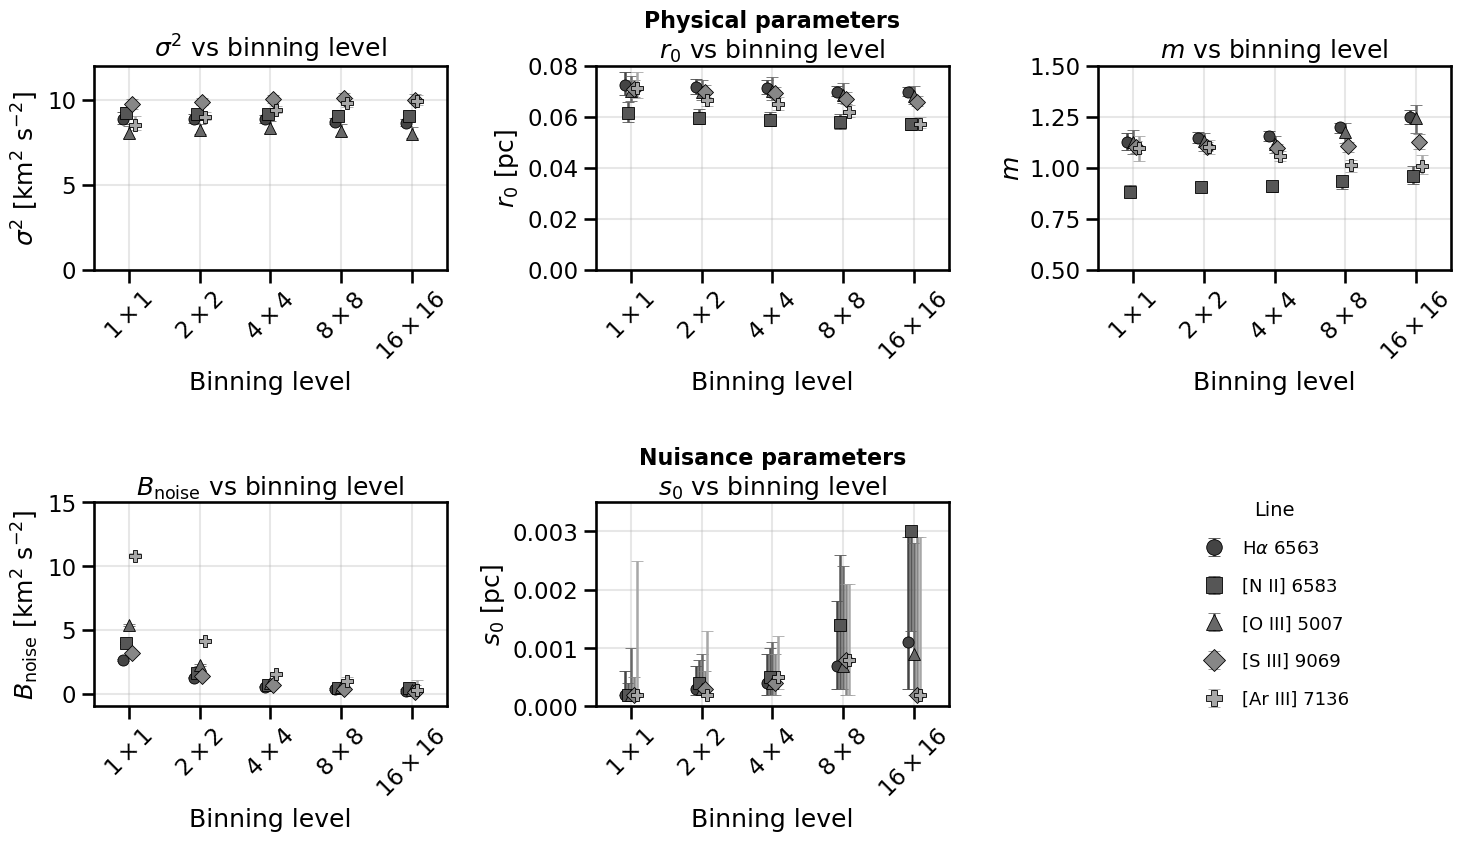

In [6]:

fig, axes = plot_param_grid_lines_bins(
    data_in,
    line_order=("H", "N", "O", "S", "Ar"),
    bin_levels=(0, 1, 2, 3, 4),
    xtick_labels=[r"$1 \times 1$", 
                  r"$2 \times 2$", 
                  r"$4 \times 4$",
                  r"$8 \times 8$", 
                  r"$16 \times 16$"],
    line_legend_labels=line_legend_labels,
    param_labels=param_labels,
    param_titles=param_titles,
    param_ylims=param_ylims,
    row_titles=("Physical parameters", "Nuisance parameters"),
    row_title_fontsize=16,
    decimals=4,
    figsize=(15, 9),
    markersize=8,
    jitter=0.08,
    save=True,
    savepath="fit_parameters_grid_2.pdf",
)

Seeing in arcsec

In [7]:
data_in[0]['meta']['PC']

0.001987736092549097

In [8]:
data_in[0]['fit']

,sig2,r0,m,s0,noise
0,8.884553,0.072300,1.128437,0.000199,2.614909
1,0.398837,0.005180,0.041207,0.000443,0.075701
2,0.310497,0.003908,0.041804,-0.000004,0.044328


In [9]:
(data_in[0]['fit'].s0/data_in[0]['meta']['PC'])*2.35

0    0.235000
1    0.523510
2   -0.005034
Name: s0, dtype: float64

In [10]:
len(data_in)

25

In [11]:
for i in range(len(data_in)):
    data_in[i]['fit']['s0'] = (
        (data_in[i]['fit']['s0'] / data_in[i]['meta']['PC']) * 2.35).clip(lower=0)

In [12]:
data_in[0]['fit']

,sig2,r0,m,s0,noise
0,8.884553,0.072300,1.128437,0.23500,2.614909
1,0.398837,0.005180,0.041207,0.52351,0.075701
2,0.310497,0.003908,0.041804,0.00000,0.044328


In [13]:
param_ylims = {
    "sig2": (0, 12),
    "r0": (0, 0.08),
    "m": (0.5, 1.5),
    "noise": (-1, 15),
    "s0": (0, 0.0035),
}

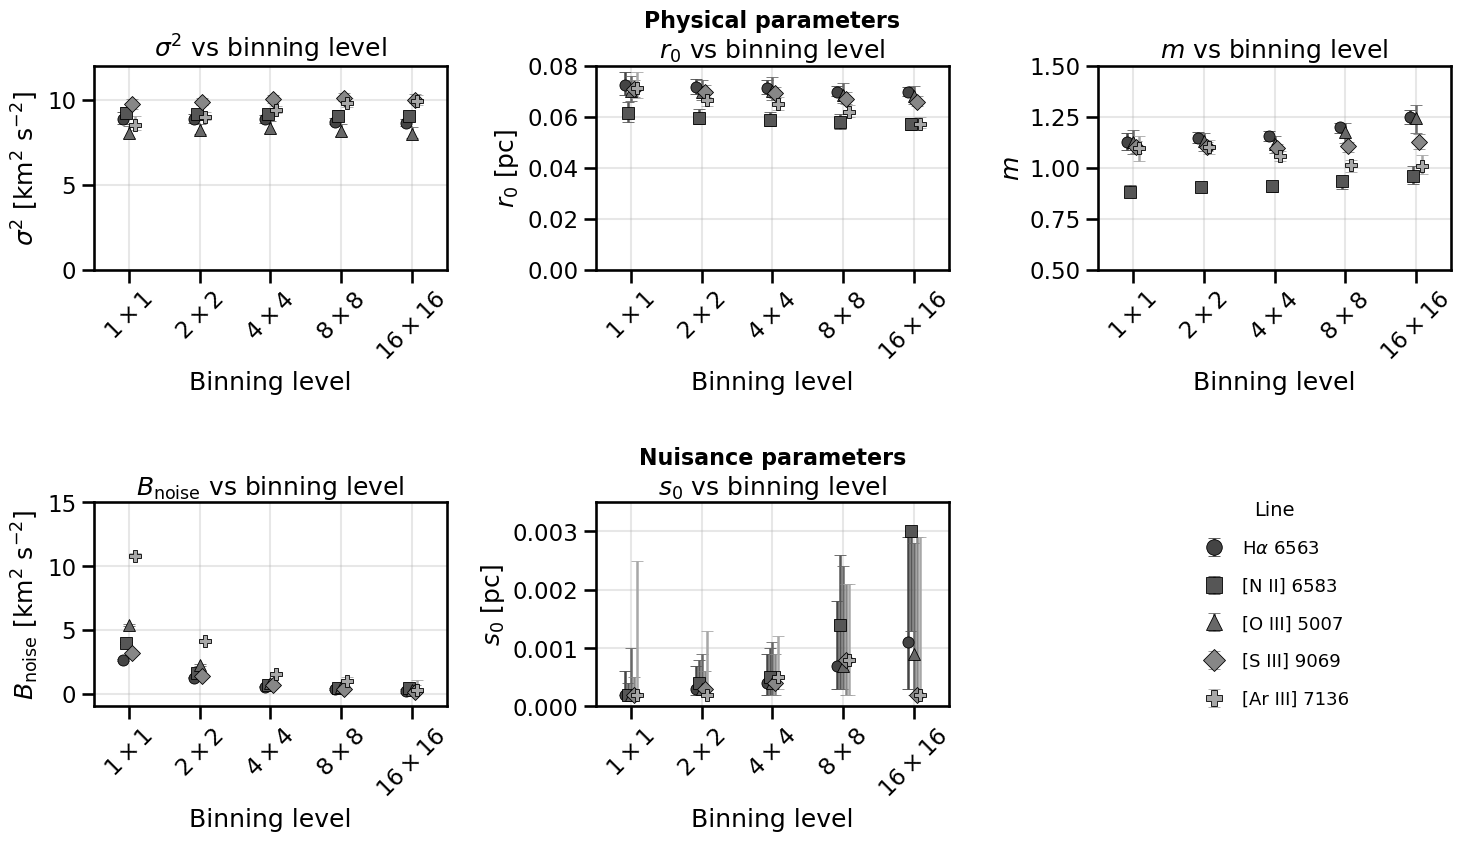

In [14]:
fig, axes = plot_param_grid_lines_bins(
    data_in,
   # params=("sig2", "r0", "m", "noise", "s0_"),
    line_order=("H", "N", "O", "S", "Ar"),
    bin_levels=(0, 1, 2, 3, 4),
    xtick_labels=[r"$1 \times 1$", 
                  r"$2 \times 2$", 
                  r"$4 \times 4$",
                  r"$8 \times 8$", 
                  r"$16 \times 16$"],
    line_legend_labels=line_legend_labels,
    param_labels=param_labels,
    param_titles=param_titles,
    param_ylims=param_ylims,
    row_titles=("Physical parameters", "Nuisance parameters"),
    row_title_fontsize=16,
    decimals=4,
    figsize=(15, 9),
    markersize=8,
    jitter=0.08,
    save=False,
    savepath="fit_parameters_grid_2_new.pdf",
)

In [15]:
for i in range(len(data_in)):
    pc = data_in[i]['meta']['PC']
    scale = 2.35 / pc

    old_value = data_in[i]['fit_dict']['s0'][0]
    old_upper = data_in[i]['fit_dict']['s0'][1]
    old_lower = data_in[i]['fit_dict']['s0'][2]

    new_value = max(0, old_value * scale)
    new_upper = old_upper * scale
    new_lower = old_lower * scale

    data_in[i]['fit_dict']['s0'] = [
        new_value,
        new_upper,
        new_lower,
    ]

In [16]:

param_labels = {
    "sig2": r"$\sigma^2$ [km$^2$ s$^{-2}$]",
    "r0": r"$r_0$ [pc]",
    "m": r"$m$",
    "noise": r"$B_\mathrm{noise}$ [km$^2$ s$^{-2}$]",
    "s0": r"$s_0$ [arcsec]",
}


param_ylims = {
    "sig2": (0, 12),
    "r0": (0, 0.08),
    "m": (0.5, 1.5),
    "noise": (-1, 15),
    "s0": (0, 4),
}

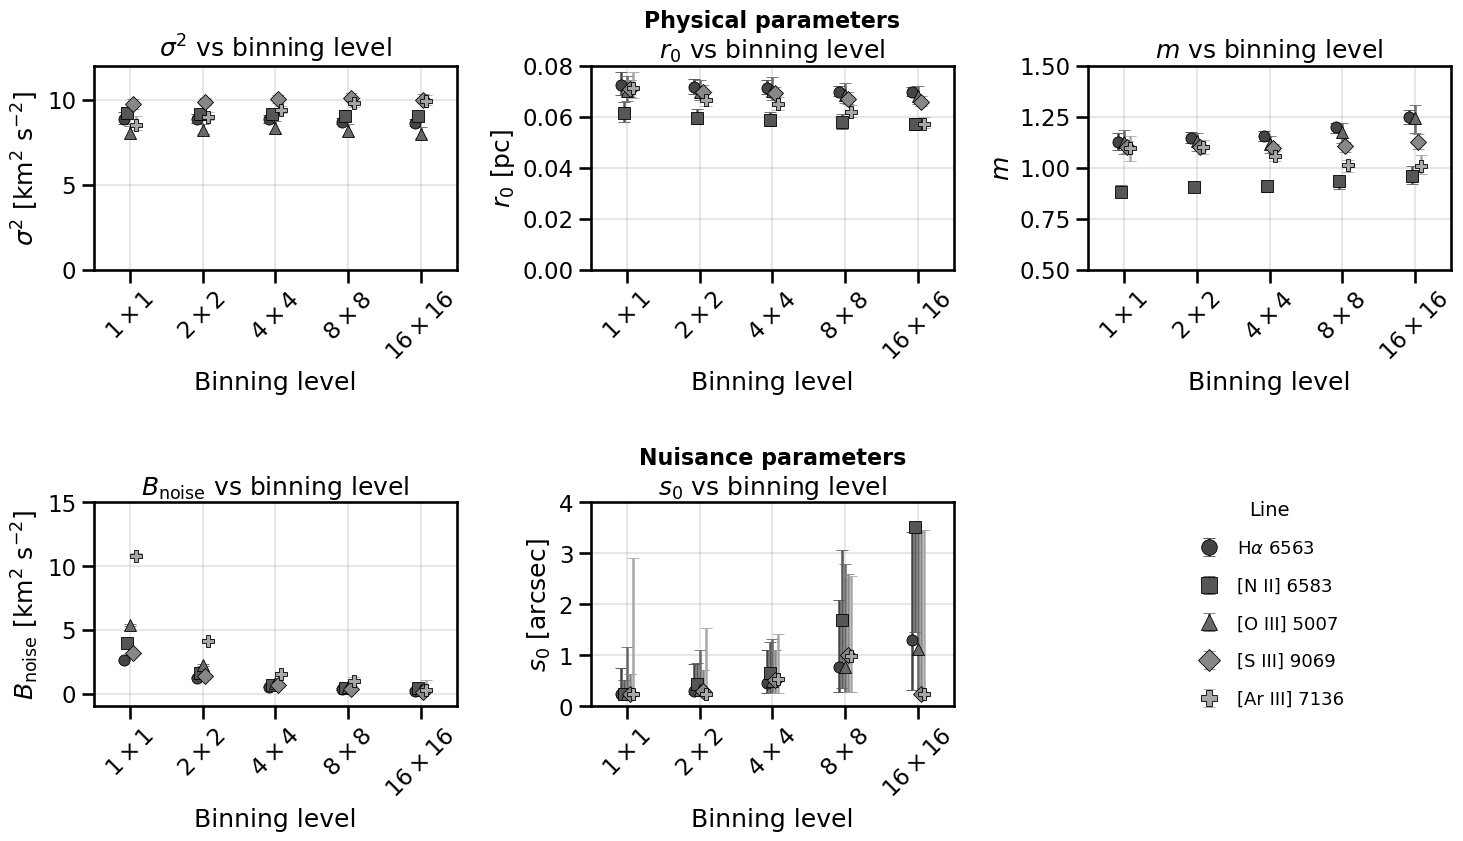

In [17]:
fig, axes = plot_param_grid_lines_bins(
    data_in,
    line_order=("H", "N", "O", "S", "Ar"),
    bin_levels=(0, 1, 2, 3, 4),
    xtick_labels=[
        r"$1 \times 1$",
        r"$2 \times 2$",
        r"$4 \times 4$",
        r"$8 \times 8$",
        r"$16 \times 16$",
    ],
    line_legend_labels=line_legend_labels,
    param_labels=param_labels,
    param_titles=param_titles,
    param_ylims=param_ylims,
    row_titles=("Physical parameters", "Nuisance parameters"),
    row_title_fontsize=16,
    decimals=4,
    figsize=(15, 9),
    markersize=8,
    jitter=0.08,
    save=True,
    savepath="fit_parameters_grid_3.pdf",
)

# Comparison

In [18]:
def load_explicit_result_samples(
    results_comp,
    maps_dir,
    samples,
    *,
    read_header=True,
    fit_key="fit",
):
    """
    Load an explicit list of fit-result samples.

    This is useful when the samples are not organized as a regular
    line/bin grid.

    Parameters
    ----------
    results_comp : module
        Module that contains load_line_bundle_mat.

    maps_dir : str or pathlib.Path
        Directory where the result files are stored.

    samples : list of dict
        Explicit sample definitions.

        Each entry should have at least:

            {
                "file_name": "MUSE-M42-H-bin0",
                "label": "MUSE H0",
                "line": "H",
                "group": "MUSE"
            }

    read_header : bool
        Passed to results_comp.load_line_bundle_mat.

    fit_key : str
        Key used to access the fit table inside each loaded bundle.

    Returns
    -------
    data_in : list of dict
        Each entry contains:

            line
            label
            group
            file_name
            bundle
            fit
            fit_dict
            meta
    """

    data_in = []

    for sample in samples:
        file_name = sample["file_name"]
        label = sample.get("label", file_name)
        line = sample.get("line", None)
        group = sample.get("group", None)

        internal_name = sample.get(
            "internal_name",
            f"{label}_line".replace(" ", "_").replace("-", "_"),
        )

        bundle = results_comp.load_line_bundle_mat(
            file_name,
            internal_name,
            maps_dir,
            read_header=read_header,
        )

        fit = bundle[fit_key]
        fit_dict = fit.to_dict(orient="list")

        entry = {
            "line": line,
            "label": label,
            "group": group,
            "file_name": file_name,
            "bundle": bundle,
            "fit": fit,
            "fit_dict": fit_dict,
            "meta": bundle.get("meta", {}),
        }

        data_in.append(entry)

    return data_in

In [19]:
samples_explicit = [
    # ------------------------------------------------------------
    # KPNO original samples
    # ------------------------------------------------------------
    {
        "file_name": "KPNO-M42-H-bin0",
        "label": "KPNO H0",
        "line": "H",
        "group": "KPNO",
    },
    {
        "file_name": "KPNO-M42-O-bin0",
        "label": "KPNO O0",
        "line": "O",
        "group": "KPNO",
    },
    {
        "file_name": "KPNO-M42-N-bin0",
        "label": "KPNO N0",
        "line": "N",
        "group": "KPNO",
    },
    {
        "file_name": "KPNO-M42-S-bin0",
        "label": "KPNO S0",
        "line": "S",
        "group": "KPNO",
    },

    # ------------------------------------------------------------
    # MUSE trimmed samples
    # ------------------------------------------------------------
    {
        "file_name": "MUSE-M42-H-bin0_trim",
        "label": "MUSE H0 trim",
        "line": "H",
        "group": "MUSE trim",
    },
    {
        "file_name": "MUSE-M42-O-bin0_trim",
        "label": "MUSE O0 trim",
        "line": "O",
        "group": "MUSE trim",
    },
    {
        "file_name": "MUSE-M42-N-bin0_trim",
        "label": "MUSE N0 trim",
        "line": "N",
        "group": "MUSE trim",
    },

    # ------------------------------------------------------------
    # MUSE selected samples
    # ------------------------------------------------------------
    {
        "file_name": "MUSE-M42-H-bin0",
        "label": "MUSE H0",
        "line": "H",
        "group": "MUSE",
    },
    {
        "file_name": "MUSE-M42-N-bin0",
        "label": "MUSE N0",
        "line": "N",
        "group": "MUSE",
    },
    {
        "file_name": "MUSE-M42-S-bin0",
        "label": "MUSE S0",
        "line": "S2",
        "group": "MUSE",
    },
    {
        "file_name": "MUSE-M42-O-bin1",
        "label": "MUSE O1",
        "line": "O",
        "group": "MUSE",
    },
    {
        "file_name": "MUSE-M42-Ar-bin2",
        "label": "MUSE Ar2",
        "line": "Ar",
        "group": "MUSE",
    },
]

In [20]:
data_explicit = load_explicit_result_samples(
    results_comp,
    MAPS_DIR,
    samples_explicit,
    read_header=True,
)

In [21]:
def plot_param_grid_lines_as_x(
    data_in,
    *,
    params=("sig2", "r0", "m", "noise", "s0"),
    line_order=("H", "N", "O", "S", "S2", "Ar"),
    group_order=("KPNO", "MUSE trim", "MUSE"),
    line_labels=None,
    param_labels=None,
    param_titles=None,
    param_ylims=None,
    row_titles=("Physical parameters", "Nuisance parameters"),
    row_title_fontsize=16,
    row_title_y=1.22,
    decimals=4,
    figsize=(15, 8),
    color_palette="Greys_d",
    markers=("o", "s", "^"),
    jitter=0.10,
    capsize=4,
    elinewidth=1.8,
    markersize=7,
    legend_fontsize=13,
    legend_title_fontsize=14,
    show_values=False,
    true=None,
    save=False,
    savepath="fit_parameters_lines_as_x.pdf",
):
    """
    Plot fit parameters with emission line on the x-axis.

    Layout
    ------
    First row:
        sig2, r0, m

    Second row:
        noise, s0, legend

    Encoding
    --------
    x-axis:
        emission line, e.g. H, N, O, S, S2, Ar

    marker/color:
        sample group, e.g. KPNO, MUSE trim, MUSE

    Expected data_in format
    -----------------------
    Each entry must contain:

        entry["line"]
        entry["group"]
        entry["fit_dict"]

    where fit_dict has entries like:

        fit_dict["sig2"] = [value, upper_error, lower_error]

    Parameters
    ----------
    line_labels : None, dict, list, or tuple
        Custom x-axis labels for emission lines.

        Example:
            line_labels = {
                "H": r"H$\\alpha$",
                "N": r"[N II]",
                "O": r"[O III]",
                "S": r"[S III]",
                "S2": r"[S II]",
                "Ar": r"[Ar III]",
            }

    param_labels : None or dict
        Custom y-axis labels with units.

        Example:
            param_labels = {
                "sig2": r"$\\sigma^2$ [km$^2$ s$^{-2}$]",
                "r0": r"$r_0$ [pc]",
                "m": r"$m$",
                "noise": r"$B_\\mathrm{noise}$ [km$^2$ s$^{-2}$]",
                "s0": r"$s_0$ [pc]",
            }

    param_titles : None or dict
        Custom subplot titles. If None, compact default titles are used.

    param_ylims : None or dict
        Custom y-axis limits for each parameter.

        Example:
            param_ylims = {
                "sig2": (0, 20),
                "r0": (0, 0.15),
                "m": (0.5, 2.0),
                "noise": (0, 2),
                "s0": (0, 0.02),
            }

    row_titles : tuple, list, or None
        Row titles for the first and second rows.

        Example:
            row_titles=("Physical parameters", "Nuisance parameters")

        If None, no row titles are added.
    """

    import numpy as np
    import seaborn as sns
    from matplotlib import pyplot as plt

    if len(data_in) == 0:
        raise ValueError("data_in is empty.")

    # ------------------------------------------------------------
    # Color and marker maps by group
    # ------------------------------------------------------------
    colors = sns.color_palette(
        color_palette,
        n_colors=len(group_order),
    )[::-1]

    color_map = {
        group: colors[i]
        for i, group in enumerate(group_order)
    }

    marker_map = {
        group: markers[i % len(markers)]
        for i, group in enumerate(group_order)
    }

    # Symmetric jitter offsets centered around zero
    if len(group_order) > 1:
        jitter_offsets = np.linspace(
            -jitter,
            jitter,
            len(group_order),
        )
    else:
        jitter_offsets = np.array([0.0])

    jitter_map = {
        group: jitter_offsets[i]
        for i, group in enumerate(group_order)
    }

    # ------------------------------------------------------------
    # x-axis positions for each emission line
    # ------------------------------------------------------------
    line_x = {
        line: i
        for i, line in enumerate(line_order)
    }

    if line_labels is None:
        line_labels_final = list(line_order)

    elif isinstance(line_labels, dict):
        line_labels_final = [
            line_labels.get(line, line)
            for line in line_order
        ]

    elif isinstance(line_labels, (list, tuple)):
        if len(line_labels) != len(line_order):
            raise ValueError(
                "If line_labels is a list/tuple, it must have the same "
                "length as line_order."
            )
        line_labels_final = list(line_labels)

    else:
        raise TypeError("line_labels must be None, a dict, list, or tuple.")

    # ------------------------------------------------------------
    # Parameter titles and y-axis labels
    # ------------------------------------------------------------
    default_param_titles = {
        "sig2": r"$\sigma^2$",
        "r0": r"$r_0$",
        "m": r"$m$",
        "noise": r"$B_\mathrm{noise}$",
        "s0": r"$s_0$",
    }

    default_param_labels = {
        "sig2": r"$\sigma^2$ [km$^2$ s$^{-2}$]",
        "r0": r"$r_0$ [pc]",
        "m": r"$m$",
        "noise": r"$B_\mathrm{noise}$ [km$^2$ s$^{-2}$]",
        "s0": r"$s_0$ [pc]",
    }

    if param_titles is None:
        param_titles_final = default_param_titles
    else:
        param_titles_final = {
            **default_param_titles,
            **param_titles,
        }

    if param_labels is None:
        param_labels_final = default_param_labels
    else:
        param_labels_final = {
            **default_param_labels,
            **param_labels,
        }

    # ------------------------------------------------------------
    # Y-axis limits
    # ------------------------------------------------------------
    if param_ylims is None:
        param_ylims_final = {}
    elif isinstance(param_ylims, dict):
        param_ylims_final = param_ylims
    else:
        raise TypeError("param_ylims must be None or a dictionary.")

    # ------------------------------------------------------------
    # Optional reference values
    # ------------------------------------------------------------
    if true is None:
        true_map = {}

    elif isinstance(true, dict):
        true_map = true

    elif isinstance(true, (list, tuple)):
        true_keys = ["sig2", "r0", "m"]
        true_map = {
            key: value
            for key, value in zip(true_keys, true)
        }

    else:
        raise TypeError("true must be None, a dict, list, or tuple.")

    # ------------------------------------------------------------
    # Figure layout
    # ------------------------------------------------------------
    fig, axes = plt.subplots(
        2,
        3,
        figsize=figsize,
        sharex=False,
    )

    axes = axes.ravel()

    param_to_axis = {
        "sig2": axes[0],
        "r0": axes[1],
        "m": axes[2],
        "noise": axes[3],
        "s0": axes[4],
    }

    # ------------------------------------------------------------
    # Main plotting loop
    # ------------------------------------------------------------
    for param in params:
        if param not in param_to_axis:
            continue

        ax = param_to_axis[param]

        for entry in data_in:
            fit_dict = entry["fit_dict"]
            line = entry.get("line", None)
            group = entry.get("group", None)

            if line not in line_x:
                continue

            if group not in group_order:
                continue

            if param not in fit_dict:
                continue

            value = round(float(fit_dict[param][0]), decimals)
            upper = max(0.0, round(float(fit_dict[param][1]), decimals))
            lower = max(0.0, round(float(fit_dict[param][2]), decimals))

            x = line_x[line] + jitter_map[group]

            ax.errorbar(
                x,
                value,
                yerr=[[lower], [upper]],
                fmt=marker_map[group],
                color=color_map[group],
                markerfacecolor=color_map[group],
                markeredgecolor="black",
                markeredgewidth=0.6,
                markersize=markersize,
                capsize=capsize,
                elinewidth=elinewidth,
                linestyle="none",
            )

            if show_values:
                ax.text(
                    x,
                    value,
                    f"{value:.{decimals}f}",
                    ha="center",
                    va="bottom",
                    fontsize=8,
                )

        if param in true_map and true_map[param] is not None:
            ax.axhline(
                true_map[param],
                color="red",
                linestyle="--",
                linewidth=1.2,
                label="Reference",
            )

        ax.set_title(
            param_titles_final.get(param, param) + " vs emission line"
        )
        ax.set_ylabel(param_labels_final.get(param, param))
        ax.grid(alpha=0.3)

        # Apply custom y-axis range if requested
        if param in param_ylims_final and param_ylims_final[param] is not None:
            ax.set_ylim(param_ylims_final[param])

    # ------------------------------------------------------------
    # Common x-axis formatting
    # ------------------------------------------------------------
    x_positions = np.arange(len(line_order))

    for ax in axes[:5]:
        ax.set_xticks(x_positions)
        ax.set_xticklabels(line_labels_final, rotation=45)
        ax.set_xlim(-0.5, len(line_order) - 0.5)
        ax.set_xlabel("Emission line")

    # ------------------------------------------------------------
    # Row titles
    # ------------------------------------------------------------
    if row_titles is not None:
        if len(row_titles) != 2:
            raise ValueError("row_titles must contain exactly two entries.")

        axes[1].annotate(
            row_titles[0],
            xy=(0.5, row_title_y),
            xycoords="axes fraction",
            ha="center",
            va="center",
            fontsize=row_title_fontsize,
            fontweight="bold",
        )

        axes[4].annotate(
            row_titles[1],
            xy=(0.5, row_title_y),
            xycoords="axes fraction",
            ha="center",
            va="center",
            fontsize=row_title_fontsize,
            fontweight="bold",
        )

    # ------------------------------------------------------------
    # Legend in the empty sixth panel
    # ------------------------------------------------------------
    legend_ax = axes[5]
    legend_ax.axis("off")

    legend_handles = []

    used_groups = {
        entry.get("group", None)
        for entry in data_in
    }

    for group in group_order:
        if group not in used_groups:
            continue

        handle = plt.Line2D(
            [0],
            [0],
            marker=marker_map[group],
            color="none",
            markerfacecolor=color_map[group],
            markeredgecolor="black",
            markeredgewidth=0.6,
            markersize=markersize + 2,
            label=group,
        )

        legend_handles.append(handle)

    if len(legend_handles) > 0:
        legend_ax.legend(
            handles=legend_handles,
            loc="center",
            frameon=False,
            title="Sample",
            fontsize=legend_fontsize,
            title_fontsize=legend_title_fontsize,
            markerscale=1.4,
            handlelength=1.5,
            labelspacing=1.1,
        )

    fig.tight_layout()

    if save:
        fig.savefig(savepath, bbox_inches="tight")

    return fig, axes

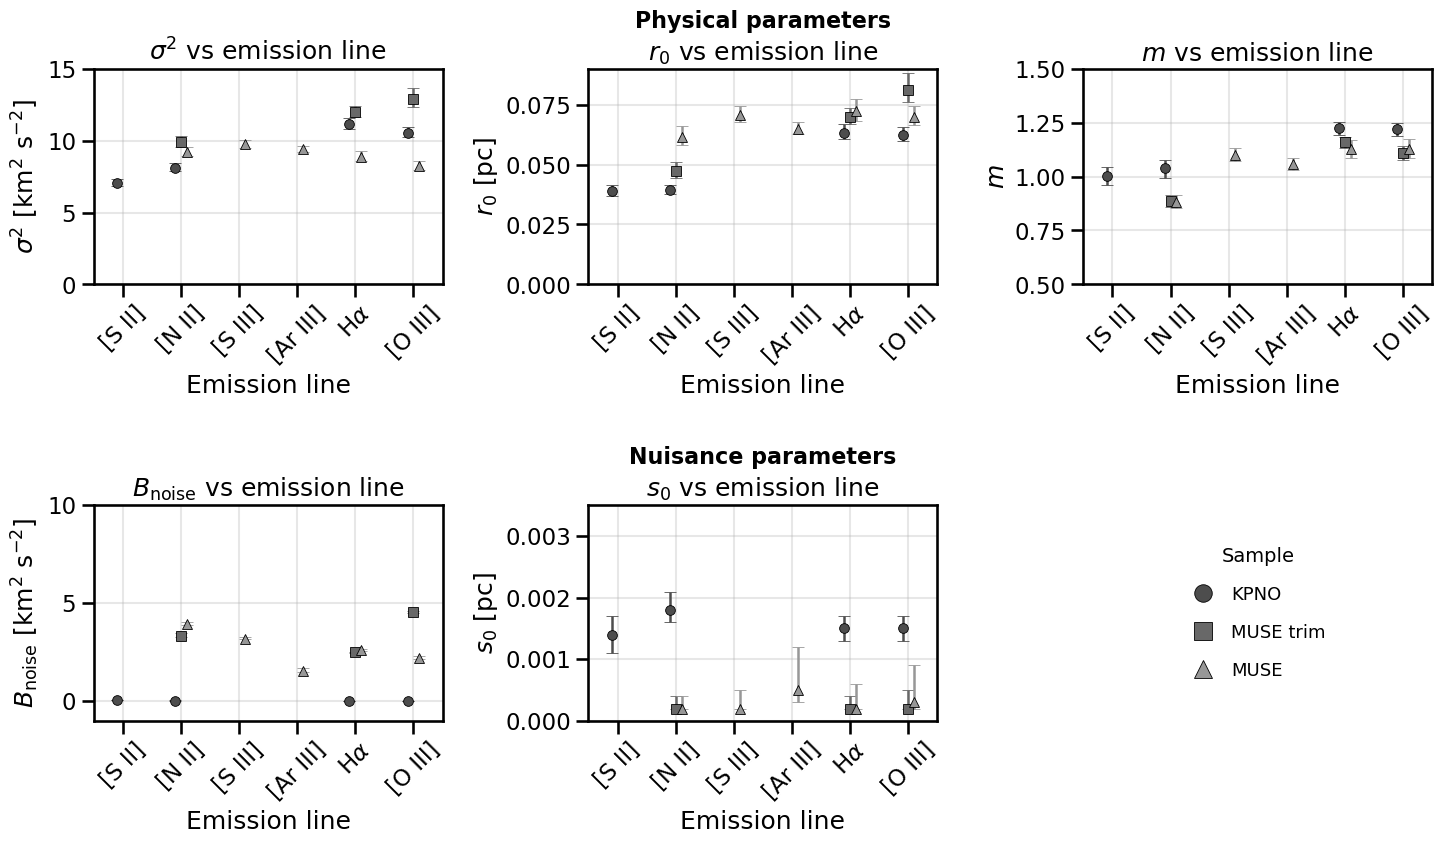

In [22]:

param_labels = {
    "sig2": r"$\sigma^2$ [km$^2$ s$^{-2}$]",
    "r0": r"$r_0$ [pc]",
    "m": r"$m$",
    "noise": r"$B_\mathrm{noise}$ [km$^2$ s$^{-2}$]",
    "s0": r"$s_0$ [pc]",
}

param_titles = {
    "sig2": r"$\sigma^2$",
    "r0": r"$r_0$",
    "m": r"$m$",
    "noise": r"$B_\mathrm{noise}$",
    "s0": r"$s_0$",
}


line_labels = {
    "H": r"H$\alpha$",
    "N": r"[N II]",
    "O": r"[O III]",
    "S": r"[S II]",
    "S2": r"[S III]",
    "Ar": r"[Ar III]",
}

param_ylims = {
    "sig2": (0, 15),
    "r0": (0, 0.09),
    "m": (0.5, 1.5),
    "noise": (-1, 10),
    "s0": (0, 0.0035),
}

fig, axes = plot_param_grid_lines_as_x(
    data_explicit,
    line_order=("S", "N", "S2", "Ar", "H", "O"),
    group_order=("KPNO", "MUSE trim", "MUSE"),
    line_labels=line_labels,
    param_labels=param_labels,
    param_titles=param_titles,
    param_ylims=param_ylims,
    row_titles=("Physical parameters", "Nuisance parameters"),
    row_title_fontsize=16,
    row_title_y=1.22,
    decimals=4,
    figsize=(15, 9),
    jitter=0.10,
    save=False,
    savepath="fit_parameters_grid_comparison_2.pdf",
)

In [24]:
for i in range(len(data_explicit)):
    pc = data_explicit[i]['meta']['PC']
    scale = 2.35 / pc

    old_value = data_explicit[i]['fit_dict']['s0'][0]
    old_upper = data_explicit[i]['fit_dict']['s0'][1]
    old_lower = data_explicit[i]['fit_dict']['s0'][2]

    new_value = max(0, old_value * scale)
    new_upper = old_upper * scale
    new_lower = old_lower * scale

    data_explicit[i]['fit_dict']['s0'] = [
        new_value,
        new_upper,
        new_lower,
    ]

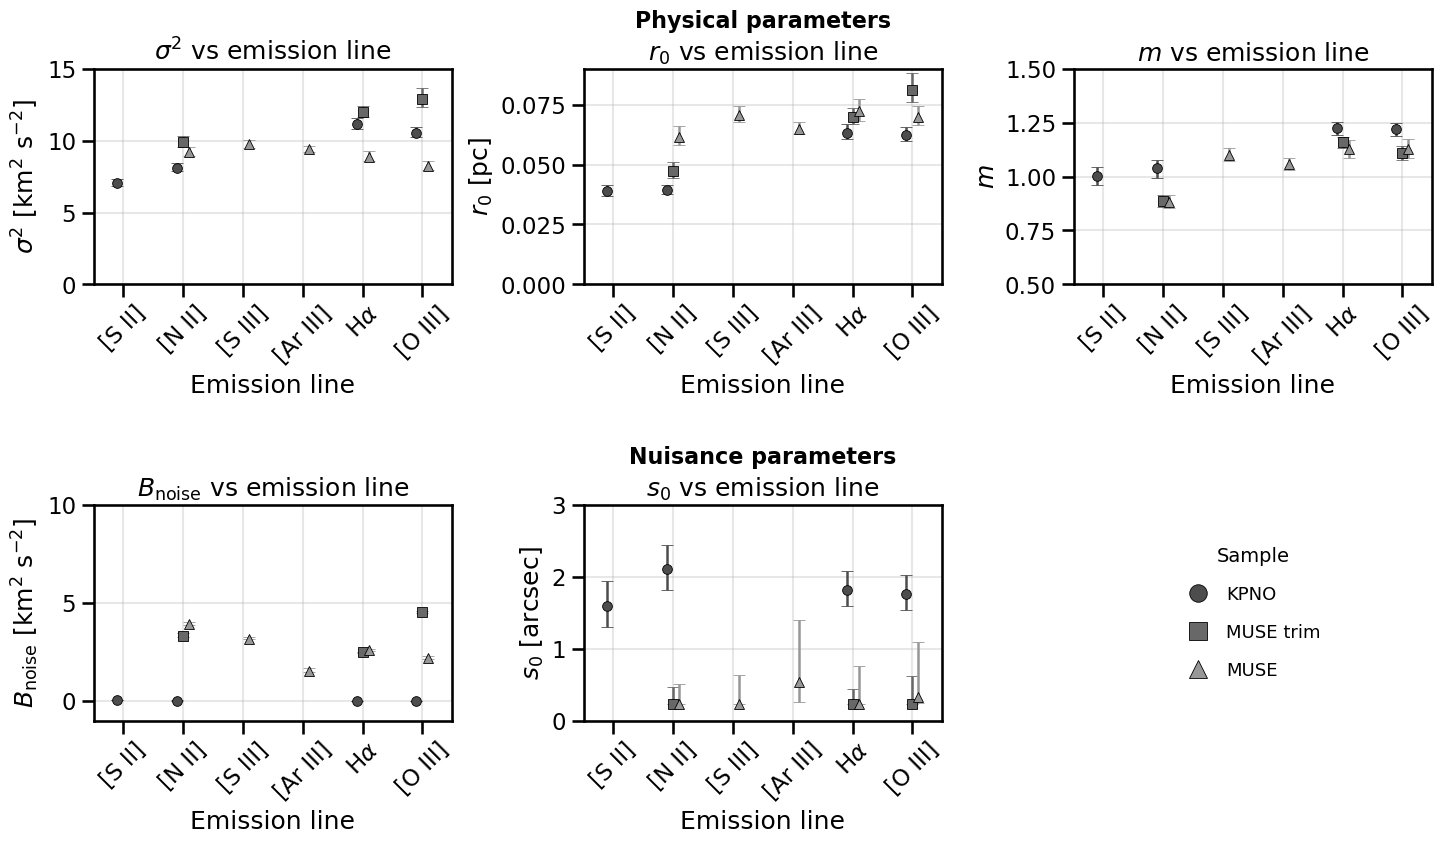

In [28]:
param_ylims = {
    "sig2": (0, 15),
    "r0": (0, 0.09),
    "m": (0.5, 1.5),
    "noise": (-1, 10),
    "s0": (0, 3),
}


param_labels = {
    "sig2": r"$\sigma^2$ [km$^2$ s$^{-2}$]",
    "r0": r"$r_0$ [pc]",
    "m": r"$m$",
    "noise": r"$B_\mathrm{noise}$ [km$^2$ s$^{-2}$]",
    "s0": r"$s_0$ [arcsec]",
}


fig, axes = plot_param_grid_lines_as_x(
    data_explicit,
    line_order=("S", "N", "S2", "Ar", "H", "O"),
    group_order=("KPNO", "MUSE trim", "MUSE"),
    line_labels=line_labels,
    param_labels=param_labels,
    param_titles=param_titles,
    param_ylims=param_ylims,
    row_titles=("Physical parameters", "Nuisance parameters"),
    row_title_fontsize=16,
    row_title_y=1.22,
    decimals=4,
    figsize=(15, 9),
    jitter=0.10,
    save=True,
    savepath="fit_parameters_grid_comparison_3.pdf",
)